# LocoSense — Phase 3: Model Training

**Input:** `data/processed/train.csv`, `val.csv`, `test.csv`  
**Output:** `models/xgb_model.pkl`, `models/lstm_model.h5`

| Step | Task |
|------|------|
| 1 | Load preprocessed splits |
| 2 | Baseline XGBoost (default params) |
| 3 | Tune XGBoost with GridSearchCV |
| 4 | Evaluate on val set — metrics + ROC |
| 5 | Threshold tuning (precision vs recall) |
| 6 | Final evaluation on test set |
| 7 | Save model + feature list |
| 8 | Optional LSTM (sequence model) |

---
## Cell 1 — Imports

In [1]:
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
import joblib

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
FIGURES_DIR   = ROOT / 'reports' / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

for f in ['train.csv', 'val.csv', 'test.csv', 'preprocessing_meta.json']:
    assert (PROCESSED_DIR / f).exists(), f'Missing {f} — run 02_preprocessing.ipynb first'

print(f'Python  : {sys.version.split()[0]}')
print(f'XGBoost : {__import__("xgboost").__version__}')
print('Imports OK ✓')

Python  : 3.9.6
XGBoost : 2.1.4
Imports OK ✓


---
## Cell 2 — Load data

In [2]:
# Load splits
train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df   = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test.csv')

# Load metadata from Phase 2
with open(PROCESSED_DIR / 'preprocessing_meta.json') as f:
    meta = json.load(f)

FEATURE_COLS     = meta['feature_cols']
TARGET           = meta['target_col']
SCALE_POS_WEIGHT = meta['scale_pos_weight']

# Build X / y splits
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f'Features         : {len(FEATURE_COLS)}')
print(f'Train            : {X_train.shape}  —  {y_train.mean()*100:.1f}% failure')
print(f'Val              : {X_val.shape}  —  {y_val.mean()*100:.1f}% failure')
print(f'Test             : {X_test.shape}  —  {y_test.mean()*100:.1f}% failure')
print(f'scale pos weight : {SCALE_POS_WEIGHT}')

Features         : 87
Train            : (4979, 87)  —  50.4% failure
Val              : (802, 87)  —  50.4% failure
Test             : (1144, 87)  —  50.3% failure
scale pos weight : 1.0


---
## Cell 3 — Baseline XGBoost

Train with sensible defaults first — this is your benchmark to beat during tuning.

In [3]:
xgb_baseline = XGBRegressor(
    n_estimators     = 200,
    learning_rate    = 0.1,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'rmse',
    random_state     = 42,
    n_jobs           = -1,
)
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

val_preds_base = xgb_baseline.predict(X_val).clip(0, 1)
rmse_base = root_mean_squared_error(y_val, val_preds_base)
mae_base  = mean_absolute_error(y_val, val_preds_base)
r2_base   = r2_score(y_val, val_preds_base)

print('Baseline XGBRegressor')
print(f'RMSE : {rmse_base:.4f}')
print(f'MAE  : {mae_base:.4f}')
print(f'R²   : {r2_base:.4f}')



Baseline XGBRegressor
RMSE : 0.0058
MAE  : 0.0043
R²   : 0.9996


---
## Cell 4 — Hyperparameter tuning with GridSearchCV


In [4]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

xgb_cv = XGBRegressor(
    eval_metric  = 'rmse',
    random_state = 42,
    n_jobs       = -1,
)

cv = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_cv,
    param_grid,
    cv = cv,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = -1,
    verbose = 1,
)

grid_search.fit(X_train, y_train)

print(f'Best ROC AUC (CV): {grid_search.best_score_:.4f}')
print(f'Best params:')
for k, v in grid_search.best_params_.items():
    print(f'{k:<22} {v}')

Fitting 3 folds for each of 48 candidates, totalling 144 fits


Best ROC AUC (CV): -0.0038
Best params:
colsample_bytree       0.9
learning_rate          0.05
max_depth              6
n_estimators           400
subsample              0.7


---
## Cell 5 — Train final XGBoost with best params

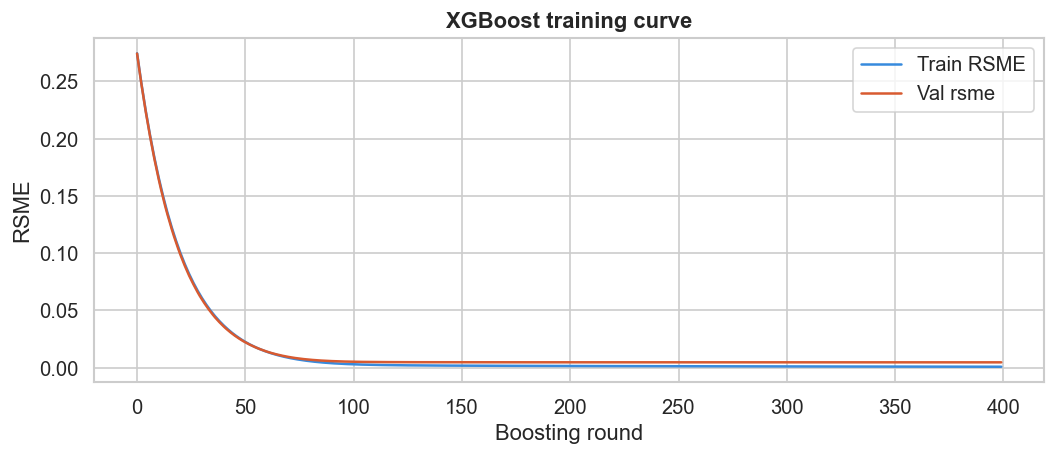

In [5]:
best_params = grid_search.best_params_

xgb_model = XGBRegressor(
    **best_params,
    eval_metric= 'rmse',
    random_state = 42,
    n_jobs= -1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Training curve
results= xgb_model.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse,label='Train RSME',color='#378ADD')
ax.plot(val_rmse,label='Val rsme',color='#D85A30')
ax.set_xlabel('Boosting round')
ax.set_ylabel('RSME')
ax.set_title('XGBoost training curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xgb_training_curve.png')
plt.show()

---
## Cell 6 — Evaluate on val set

Validation Results
RMSE : 0.004608
MAE  : 0.003298
R²   : 0.999745


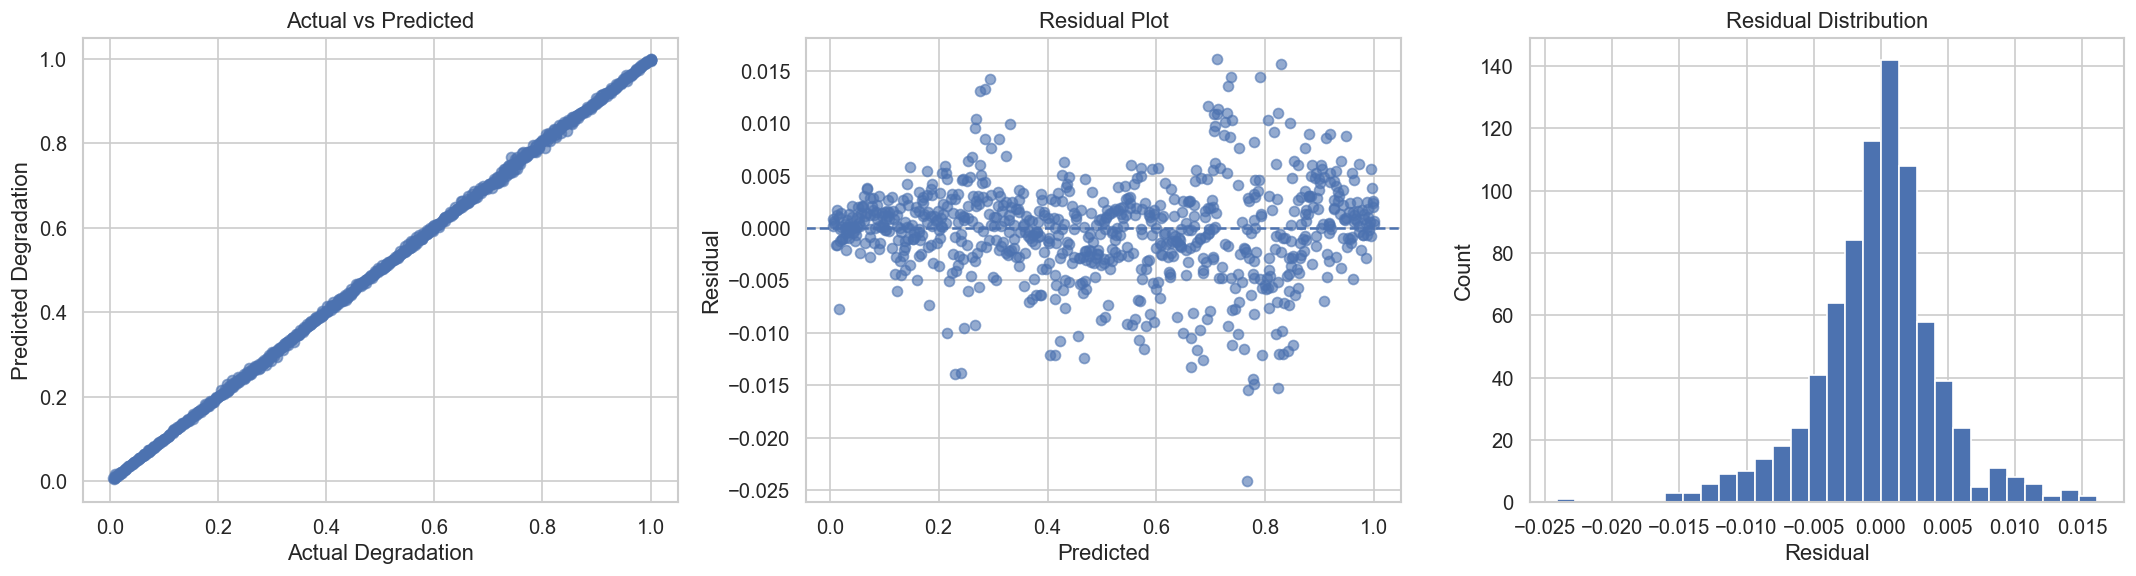

In [6]:
# Predict
val_preds = xgb_model.predict(X_val).clip(0, 1)

# Metrics
rmse = root_mean_squared_error(y_val, val_preds)
mae = mean_absolute_error(y_val, val_preds)
roc_auc = r2_score(y_val, val_preds)

print("Validation Results")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {roc_auc:.6f}")


fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(
    y_val,
    val_preds,
    alpha=0.6
)

axes[0].plot(
    [0,1],
    [0,1],
    '--',
    linewidth=2
)

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Degradation")
axes[0].set_ylabel("Predicted Degradation")


residuals = y_val - val_preds

axes[1].scatter(
    val_preds,
    residuals,
    alpha=0.6
)

axes[1].axhline(
    y=0,
    linestyle='--'
)

axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")


axes[2].hist(
    residuals,
    bins=30
)

axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_validation_results.png")
plt.show()

In [7]:
# val_preds = xgb_model.predict(X_val).clip(0, 1)

# roc_auc = r2_score(y_val, val_preds)    
# ap      = root_mean_squared_error(y_val, val_preds)

# print(f'ROAUC: {roc_auc:.4f}')
# print(f'Avg precion: {ap:.4f}')
# print(f'Baseline ROC UC: {roc_auc:.4f}  (improvement: {roc_auc - roc_auc:+.4f})')
# print()
# print(classification_report(y_val, val_preds, target_names=['No failure','Failure']))

# #  ROC + PR curves & Confusion matrix
# fig = plt.figure(figsize=(16, 5))
# gs= gridspec.GridSpec(1, 3, figure=fig)

# # ROC
# ax1 = fig.add_subplot(gs[0])
# fpr, tpr, _ = roc_curve(y_val, val_preds)
# ax1.plot(fpr, tpr, color='#378ADD', linewidth=2, label=f'AUC = {roc_auc:.3f}')
# ax1.plot([0,1],[0,1],'--', color='gray', linewidth=1)
# ax1.set_xlabel('False positive rate')
# ax1.set_ylabel('True positive rate')
# ax1.set_title('ROC curve', fontweight='bold')
# ax1.legend()

# # Precision-Recall
# ax2 = fig.add_subplot(gs[1])
# prec,rec, _ = precision_recall_curve(y_val, val_preds)
# ax2.plot(rec, prec,color='#1D9E75', linewidth=2, label=f'AP = {ap:.3f}')
# ax2.axhline(y_val.mean(),color='gray',linestyle='--',linewidth=1,label=f'Baseline = {y_val.mean():.3f}')
# ax2.set_xlabel('Recall')
# ax2.set_ylabel('Precision')
# ax2.set_title('Precision-Recall curve',fontweight='bold')
# ax2.legend()

# # Confusion matrix
# ax3 = fig.add_subplot(gs[2])
# cm = confusion_matrix(y_val, val_preds)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['No failure','Failure'],
#             yticklabels=['No failure','Failure'], ax=ax3)
# ax3.set_xlabel('Predicted')
# ax3.set_ylabel('Actual')
# ax3.set_title('Confusion matrix (val)', fontweight='bold')
# plt.suptitle('XGBoost —validation set evaluation', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'xgb_val_evaluation.png')
# plt.show()

---
## Cell 7 — Threshold tuning

In [8]:
BEST_THRESHOLD = 0.5  
print('Regressor output is continuous 0–1 — no threshold needed')
# hresholds = np.arange(0.1, 0.9, 0.01)
# f1_scores, prec_scores, rec_scores = [], [], []

# for t in thresholds:
#     preds_t = (val_proba >= t).astype(int)
#     f1_scores.append(f1_score(y_val,preds_t,zero_division=0))
#     prec_scores.append(precision_score(y_val, preds_t,zero_division=0))
#     rec_scores.append(recall_score(y_val, preds_t,zero_division=0))

# best_idx= np.argmax(f1_scores)
# BEST_THRESHOLD = round(float(thresholds[best_idx]), 2)

# fig, ax = plt.subplots(figsize=(9, 4))
# ax.plot(thresholds, f1_scores,label='F1',color='#534AB7', linewidth=2)
# ax.plot(thresholds, prec_scores,label='Precision',color='#1D9E75', linewidth=1.5, linestyle='--')
# ax.plot(thresholds, rec_scores,label='Recall',color='#D85A30', linewidth=1.5, linestyle='--')
# ax.axvline(BEST_THRESHOLD, color='black',linestyle=':',linewidth=1.5,
#            label=f'Best threshold = {BEST_THRESHOLD}')
# ax.set_xlabel('Decision threshold')
# ax.set_ylabel('Score')
# ax.set_title('Threshold tuning F1, Precision, Recall', fontweight='bold')
# ax.legend()
# plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'xgb_threshold_tuning.png')
# plt.show()

# print(f'Best threshold:{BEST_THRESHOLD}')
# print(f'F1:{f1_scores[best_idx]:.4f}')
# print(f'Precision : {prec_scores[best_idx]:.4f}')
# print(f'Recall: {rec_scores[best_idx]:.4f}')

Regressor output is continuous 0–1 — no threshold needed


---
## Cell 8 — Final evaluation on test set

FINAL TEST SET RESULTS
R²   : 0.9998
MAE  : 0.0031
RMSE : 0.0044


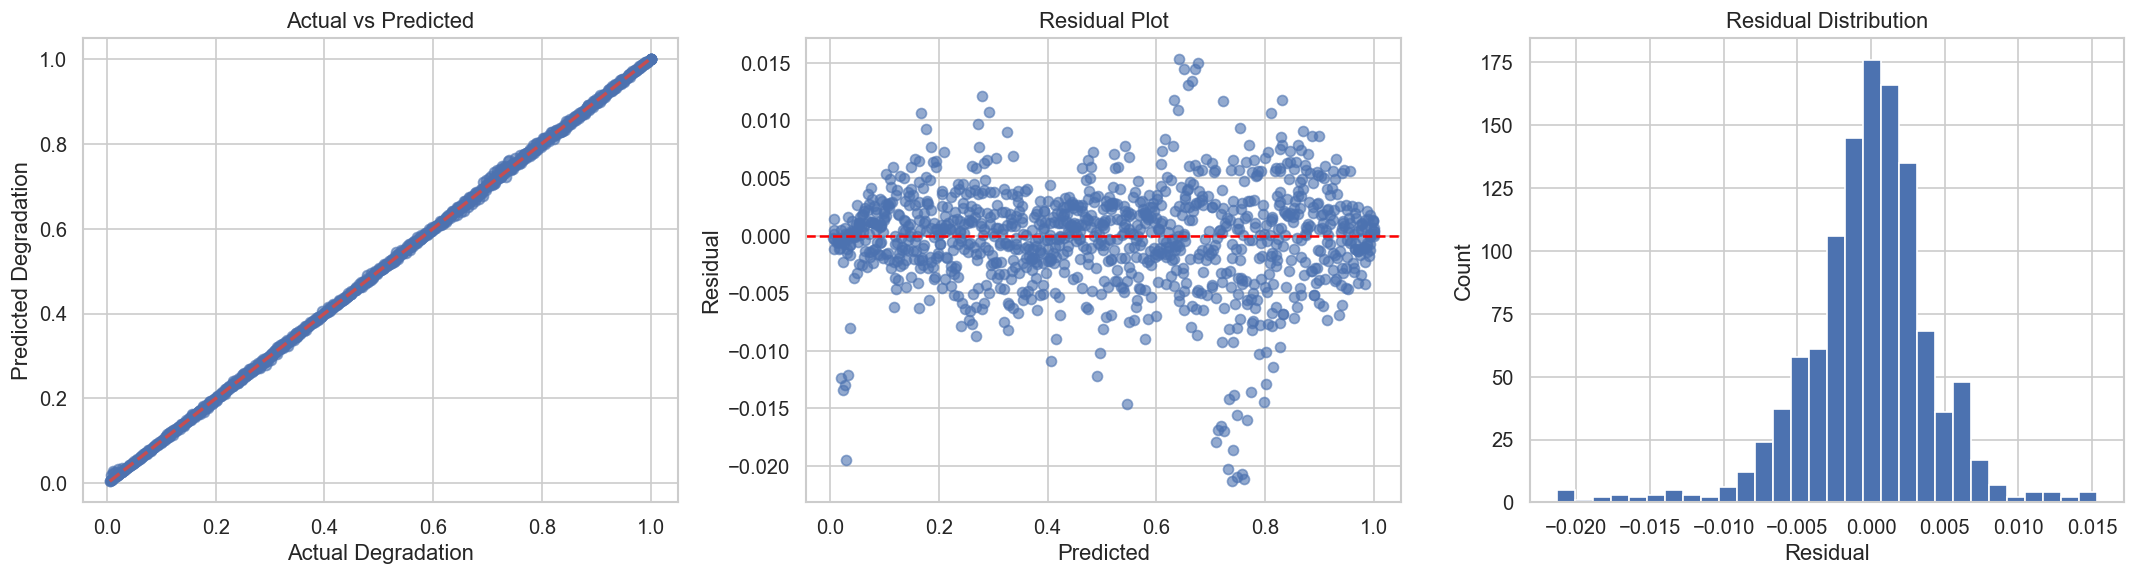

In [9]:
test_preds = xgb_model.predict(X_test).clip(0, 1)

# Metrics
test_rmse = root_mean_squared_error(y_test, test_preds)
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)
print(f"R²   : {test_r2:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")

# =====================================
# Visualization
# =====================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------------
# 1. Actual vs Predicted
# -------------------------------------

axes[0].scatter(y_test, test_preds, alpha=0.6)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Degradation")
axes[0].set_ylabel("Predicted Degradation")

# -------------------------------------
# 2. Residual Plot
# -------------------------------------

residuals = y_test - test_preds

axes[1].scatter(test_preds, residuals, alpha=0.6)

axes[1].axhline(0, color='red', linestyle='--')

axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

# -------------------------------------
# 3. Residual Distribution
# -------------------------------------

axes[2].hist(residuals, bins=30)

axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_test_results.png")
plt.show()

In [10]:
# test_preds = xgb_model.predict(X_test).clip(0, 1)

# test_roc = r2_score(y_test, test_preds)
# test_f1  = mean_absolute_error(y_test, test_preds)
# test_ap  = root_mean_squared_error(y_test, test_preds)

# print('=' * 50)
# print('  FINAL TEST SET RESULTS')
# print('=' * 50)
# print(f'  R²   : {test_roc:.4f}')
# print(f'  MAE  : {test_f1:.4f}')
# print(f'  RMSE : {test_ap:.4f}')
# print(f'ROC-AUC: {test_roc:.4f}')
# print(f'  Avg precision : {test_ap:.4f}')
# print(f'F1 score: {test_f1:.4f}')
# print(f'Threshold: {BEST_THRESHOLD}')
# print()
# print(classification_report(y_test,test_preds,target_names=['No failure','Failure']))

# # Confusion matrix
# fig, axes = plt.subplots(1, 2,figsize=(12, 4))

# cm_test = confusion_matrix(y_test,test_preds)
# sns.heatmap(cm_test,annot=True, fmt='d', cmap='Blues',
#             xticklabels=['No failure','Failure'],
#             yticklabels=['No failure','Failure'],ax=axes[0])
# axes[0].set_xlabel('Predicted')
# axes[0].set_ylabel('Actual')
# axes[0].set_title('Confusion matrix (test)', fontweight='bold')

# # ROC 
# fpr_t, tpr_t, _ = roc_curve(y_test, test_preds)
# axes[1].plot(fpr_t, tpr_t, color='#378ADD', linewidth=2, label=f'AUC = {test_roc:.3f}')
# axes[1].plot([0,1],[0,1],'--', color='gray', linewidth=1)
# axes[1].set_xlabel('False positive rate')
# axes[1].set_ylabel('True positive rate')
# axes[1].set_title('ROC curve (test)', fontweight='bold')
# axes[1].legend()

# plt.suptitle('XGBoost final test evaluation', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'xgb_test_evaluation.png')
# plt.show()

---
## Cell 9 — Feature importance (built-in)

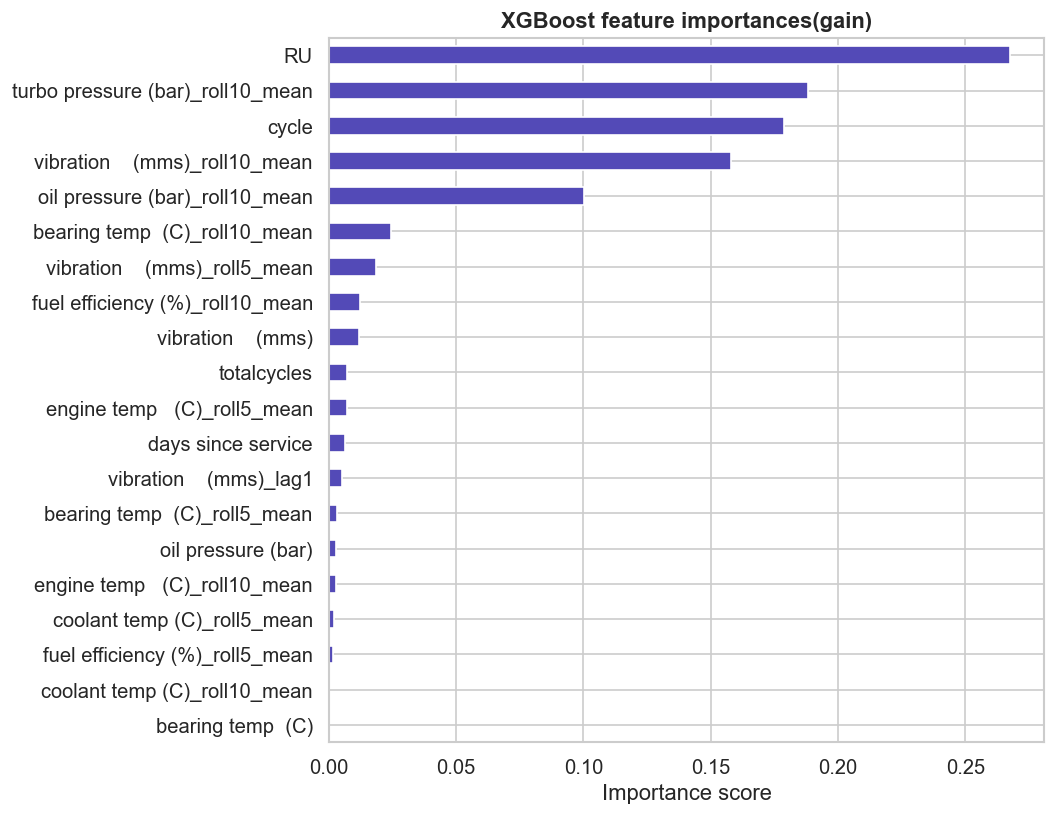

                         feature  importance
                              RU    0.267700
turbo pressure (bar)_roll10_mean    0.188135
                           cycle    0.178819
  vibration    (mms)_roll10_mean    0.157841
  oil pressure (bar)_roll10_mean    0.100219
   bearing temp  (C)_roll10_mean    0.024576
   vibration    (mms)_roll5_mean    0.018584
 fuel efficiency (%)_roll10_mean    0.012352
              vibration    (mms)    0.011979
                     totalcycles    0.007303


In [11]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
importance_df.sort_values('importance').plot.barh(
    x='feature', y='importance', ax=ax, color='#534AB7', legend=False
)
ax.set_title('XGBoost feature importances(gain)', fontweight='bold')
ax.set_xlabel('Importance score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR /'xg feature importance.png')
plt.show()
print(importance_df[['feature','importance']].head(10).to_string(index=False))

---
## Cell 10 — Save model + metadata

In [12]:
joblib.dump(xgb_model, MODELS_DIR / 'xgb_model.pkl')

# Save model metadata 
model_meta = {
    'feature_cols'    : FEATURE_COLS,
    'target_col'      : TARGET,
    'threshold'       : BEST_THRESHOLD,
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'val_roc_auc'     : round(roc_auc, 4),
    'test_roc_auc'    : round(test_rmse, 4),
    'test_f1'         : round(test_mae, 4),
    'best_params'     : best_params,
    'risk_thresholds' : {
        'Low'     : [0.0,  0.3],
        'Medium'  : [0.3,  0.5],
        'High'    : [0.5,  0.75],
        'Critical': [0.75, 1.0]
    }
}

with open(MODELS_DIR / 'model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print()
print(f'Features used: {len(FEATURE_COLS)}')
print(f'Best threshold: {BEST_THRESHOLD}')
print(f'Val  ROC AUC: {roc_auc:.4f}')
print(f'Test ROC AUC: {test_rmse:.4f}')
print(f'Test F1: {test_mae:.4f}')
print()
print('Risk bands saved in model meta.json:')
print('0.00 – 0.30  : Low')
print('0.30 – 0.50  ; Medium')
print('0.50 – 0.75  ; High')
print('0.75 – 1.00  ; Critical')


Features used: 87
Best threshold: 0.5
Val  ROC AUC: 0.9997
Test ROC AUC: 0.0044
Test F1: 0.0031

Risk bands saved in model meta.json:
0.00 – 0.30  : Low
0.30 – 0.50  ; Medium
0.50 – 0.75  ; High
0.75 – 1.00  ; Critical


---
## 11.: LSTM 

In [13]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.metrics import RootMeanSquaredError
    from sklearn.metrics import (root_mean_squared_error,mean_absolute_error,r2_score)


    RUN_LSTM = True
except ImportError:
    RUN_LSTM = False

WINDOW_SIZE = 30 

def build_sequences(df, feature_cols, target_col, window=30):
    X_seq, y_seq = [], []
    for loco_id in df['loco_id'].unique() if 'loco_id' in df.columns else [None]:
        subset = df[df['loco_id'] == loco_id].sort_values('cycle') if loco_id else df
        vals   = subset[feature_cols].values
        labels = subset[target_col].values
        for i in range(window, len(vals)):
            X_seq.append(vals[i-window:i])
            y_seq.append(labels[i])
    return np.array(X_seq), np.array(y_seq)

if RUN_LSTM:
    # Re-load raw splits with loco_id for sequencing
    train_raw = pd.read_csv(PROCESSED_DIR / 'train.csv')
    val_raw   = pd.read_csv(PROCESSED_DIR / 'val.csv')

    print('Building LSTM sequences...')
    X_tr_seq, y_tr_seq = build_sequences(train_raw, FEATURE_COLS, TARGET, WINDOW_SIZE)
    X_vl_seq, y_vl_seq = build_sequences(val_raw,   FEATURE_COLS, TARGET, WINDOW_SIZE)
    print(f'Train sequences : {X_tr_seq.shape}')
    print(f'Val sequences   : {X_vl_seq.shape}')

    # Build model
    lstm_model = Sequential([
        Input(shape=(WINDOW_SIZE, len(FEATURE_COLS))),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1,  activation='linear'),
    ])

    lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[RootMeanSquaredError(name="rmse")]
)
    lstm_model.summary()

    es = EarlyStopping(monitor='val_rmse', patience=5, restore_best_weights=True, mode='min')

    history = lstm_model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=30,
        batch_size=64,
        callbacks=[es],
        verbose=1,
    )

lstm_preds = lstm_model.predict(X_vl_seq).flatten()

lstm_rmse = root_mean_squared_error(y_vl_seq, lstm_preds)
lstm_mae = mean_absolute_error(y_vl_seq, lstm_preds)
lstm_r2 = r2_score(y_vl_seq, lstm_preds)

print("\nLSTM Validation")
print("----------------")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAE  : {lstm_mae:.4f}")
print(f"R²   : {lstm_r2:.4f}")

lstm_model.save(MODELS_DIR / 'lstm_model.h5')

Building LSTM sequences...
Train sequences : (4949, 30, 87)
Val sequences   : (772, 30, 87)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,873 (202.63 KB)

 Trainable params: 51,873 (202.63 KB)

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step

21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step



LSTM Validation
----------------
RMSE : 0.0418
MAE  : 0.0190
R²   : 0.9784
